### Approach A, using Random Forest Regression

##### Our dataset, energydata_complete.csv, is continuous so it is appropiate to start with regression metrics over classification. 



In [8]:
## Load Data, import required libraries, sklearn and matplot
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

path = "C:\Datasets" 

##Read data file
filename_read = os.path.join(path, "energydata_complete.csv")
data = pd.read_csv(filename_read)

print(data.head())
print(data.shape)
# data.info()

## SET target column, column 'Appliances'
target = "Appliances"

## DROP date column, string
## TARGET from X
X = data.drop(columns=["date", target]).values
y = data[target].values

## Train:Test split ( 25% test size ) + reproducable random state, 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

                  date  Appliances  lights     T1       RH_1    T2       RH_2  \
0  2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.790000   
1  2016-01-11 17:10:00          60      30  19.89  46.693333  19.2  44.722500   
2  2016-01-11 17:20:00          50      30  19.89  46.300000  19.2  44.626667   
3  2016-01-11 17:30:00          50      40  19.89  46.066667  19.2  44.590000   
4  2016-01-11 17:40:00          60      40  19.89  46.333333  19.2  44.530000   

      T3       RH_3         T4  ...         T9   RH_9     T_out  Press_mm_hg  \
0  19.79  44.730000  19.000000  ...  17.033333  45.53  6.600000        733.5   
1  19.79  44.790000  19.000000  ...  17.066667  45.56  6.483333        733.6   
2  19.79  44.933333  18.926667  ...  17.000000  45.50  6.366667        733.7   
3  19.79  45.000000  18.890000  ...  17.000000  45.40  6.250000        733.8   
4  19.79  45.000000  18.890000  ...  17.000000  45.40  6.133333        733.9   

   RH_out  Windspeed  Visibility

In [21]:
# R^2 : 
r2_list = []
mae_list = []
nums = []

rf = RandomForestRegressor(
    n_estimators=1,
    random_state=42,
    n_jobs=-1,
    warm_start=True
)

## Loop over trees 
for i in range(1, 129):
    rf.set_params(n_estimators=i)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    nums.append(i)
    r2_list.append(r2)
    mae_list.append(mae)

## No. of descision trees
print(f"Trees: {i:3d}")
##
print(f"R2: {r2:.4f}")
##
print(f"R2: {mae:.3f}")


Trees: 128
R2: 0.5216
R2: 32.925


#### 1. Measuring mean absolute error, mae. Computes average magnitude of a prediction error; how far a prediction is off the true value. We want this value to be as low as possible.

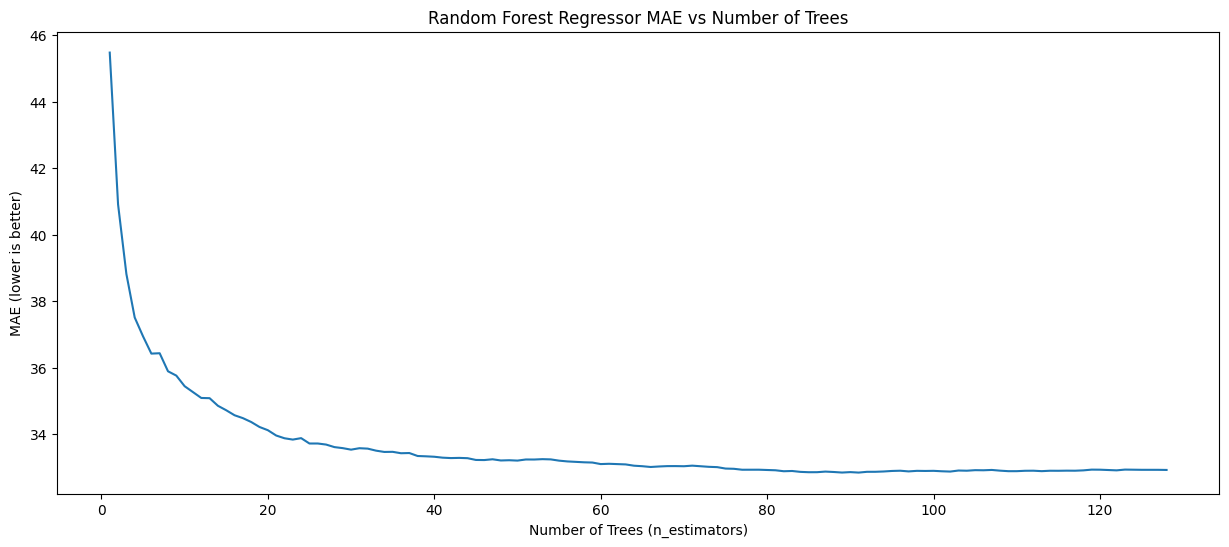

In [23]:
plt.figure(figsize=(15, 6))
plt.plot(nums, mae_list)
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("MAE (lower is better)")
plt.title("Random Forest Regressor MAE vs Number of Trees")
plt.show()


##### Observations

#### MAE stagnates around 33, this means around 33 energy units off of the average which occurs around 40 trees.

### Approach B, converting into classification
#### Testing Accuracy by utilising "Appliance" column as a cateogry, then using values that are above the median or "high-usage".

[('Tree: 1', '0.83259'), ('Tree: 2', '0.83745'), ('Tree: 3', '0.87110'), ('Tree: 4', '0.87090'), ('Tree: 5', '0.87981'), ('Tree: 6', '0.87900'), ('Tree: 7', '0.88792'), ('Tree: 8', '0.88529'), ('Tree: 9', '0.88974'), ('Tree: 10', '0.88893'), ('Tree: 11', '0.89360'), ('Tree: 12', '0.89177'), ('Tree: 13', '0.89258'), ('Tree: 14', '0.89218'), ('Tree: 15', '0.89664'), ('Tree: 16', '0.89542'), ('Tree: 17', '0.89724'), ('Tree: 18', '0.89582'), ('Tree: 19', '0.89643'), ('Tree: 20', '0.89562'), ('Tree: 21', '0.89582'), ('Tree: 22', '0.89380'), ('Tree: 23', '0.89582'), ('Tree: 24', '0.89522'), ('Tree: 25', '0.89582'), ('Tree: 26', '0.89400'), ('Tree: 27', '0.89481'), ('Tree: 28', '0.89380'), ('Tree: 29', '0.89542'), ('Tree: 30', '0.89562'), ('Tree: 31', '0.89623'), ('Tree: 32', '0.89745'), ('Tree: 33', '0.89664'), ('Tree: 34', '0.89623'), ('Tree: 35', '0.89724'), ('Tree: 36', '0.89664'), ('Tree: 37', '0.89704'), ('Tree: 38', '0.89643'), ('Tree: 39', '0.89562'), ('Tree: 40', '0.89623'), ('Tree: 

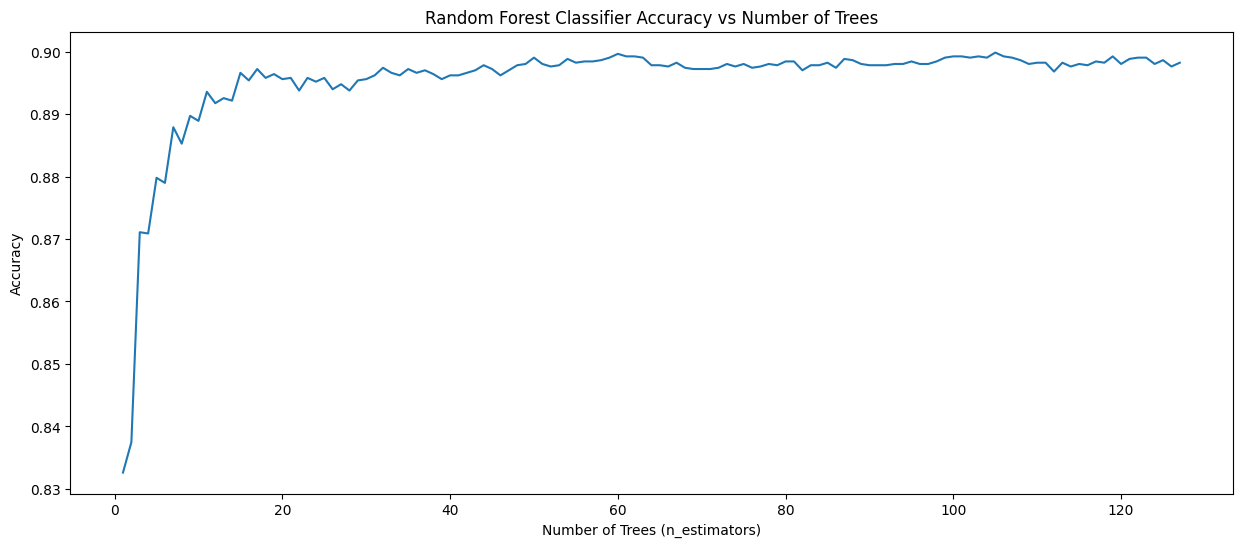

In [6]:
## Load same data, import 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

path = "C:\Datasets" 

##Read data file
filename_read = os.path.join(path, "energydata_complete.csv")
data = pd.read_csv(filename_read)
df = data

# Binary target: 1 if Appliances > median, else 0
median_val = df["Appliances"].median()
df["target"] = (df["Appliances"] > median_val).astype(int)

X = df.drop(columns=["date", "Appliances", "target"]).values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

accuracy_data = []
tree_data = []
nums2 = []


rf2 = RandomForestClassifier(
    n_estimators=1,
    criterion="entropy",
    random_state=42,
    n_jobs=-1,
    # Reuse data that has already been trained
    # Tree 1 trained once, add trees and retain 
    warm_start = True # KEEP UNCOMMENTED 
)

for i in range(1, 128):
    rf2.set_params(n_estimators=i)
    rf2.fit(X_train, y_train)
    y_pred = rf2.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    nums2.append(i)
    accuracy_data.append(acc)

    tree_data.append((f"Tree: {i}", f"{acc:.5f}"))

print(tree_data)

plt.figure(figsize=(15, 6))
plt.plot(nums2, accuracy_data)
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Random Forest Classifier Accuracy vs Number of Trees")
plt.show()


### Observations

#### No. of trees used is expotential to the level of accuracy that stagnates at around 40 trees and level the value of accuracy starts to fluctuate between 0.899 and 0.898.